In [1]:
"""
Docstring for feature_selection.ipynb

In this file feature selection is performed to optimize model performance.
    - Determining the ideal number of features to avoid the curse of dimensionality.
    - Feature selection based on correlation.
    - Feature selection based on feature importance.

Author: Esraaj Sarkar Gupta
"""
None

In [2]:
# ---- Imports ---- #
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
# ---- Functions ---- #

# -- Maximum Feature Space -- #
def calculate_max_feature_space(total_data_points, number_of_bins, epv_rule=10):
    """
    Calculates the theoretical maximum number of features (dimensionality) 
    you can safely use to avoid the Curse of Dimensionality and overfitting.
    
    Parameters:
    total_data_points (int): The total number of rows in your dataset.
    number_of_bins (int): The number of classes in your target variable (e.g., 2 for True/False).
    epv_rule (int): The Events Per Variable ratio. Default is 10.
    
    Returns:
    int: The maximum safe number of features.

    This function was generated using Gemini Pro 3.1
    """
    if number_of_bins <= 0:
        raise ValueError("Number of bins must be at least 1.")
        
    # Find the size of the minority class assuming perfectly balanced data (best-case scenario)
    best_case_minority_count = total_data_points / number_of_bins
    
    # Calculate the maximum safe features using the EPV rule
    max_features = int(best_case_minority_count / epv_rule)
    
    return max_features

In [4]:
# ---- Maximum Feature Space ---- #

_DATA_FILE_PATH = Path("../data/koi/physics_train/physically_anchored_features_KOI.csv")
data = pd.read_csv(_DATA_FILE_PATH)

number_of_datapoints = data.shape[0]

number_of_bins = data["Target"].nunique() # Expected to be 2 (True/False)

max_features = calculate_max_feature_space(number_of_datapoints, number_of_bins)

print(f"Total Data Points: {number_of_datapoints}")
print(f"Number of Bins: {number_of_bins}")
print(f"Maximum Safe Features: {max_features}")

# Authors's Note: This is a theoretical upper bound. And to be perfectly honest,
# computing this was a complete waste of time.

Total Data Points: 7713
Number of Bins: 2
Maximum Safe Features: 385


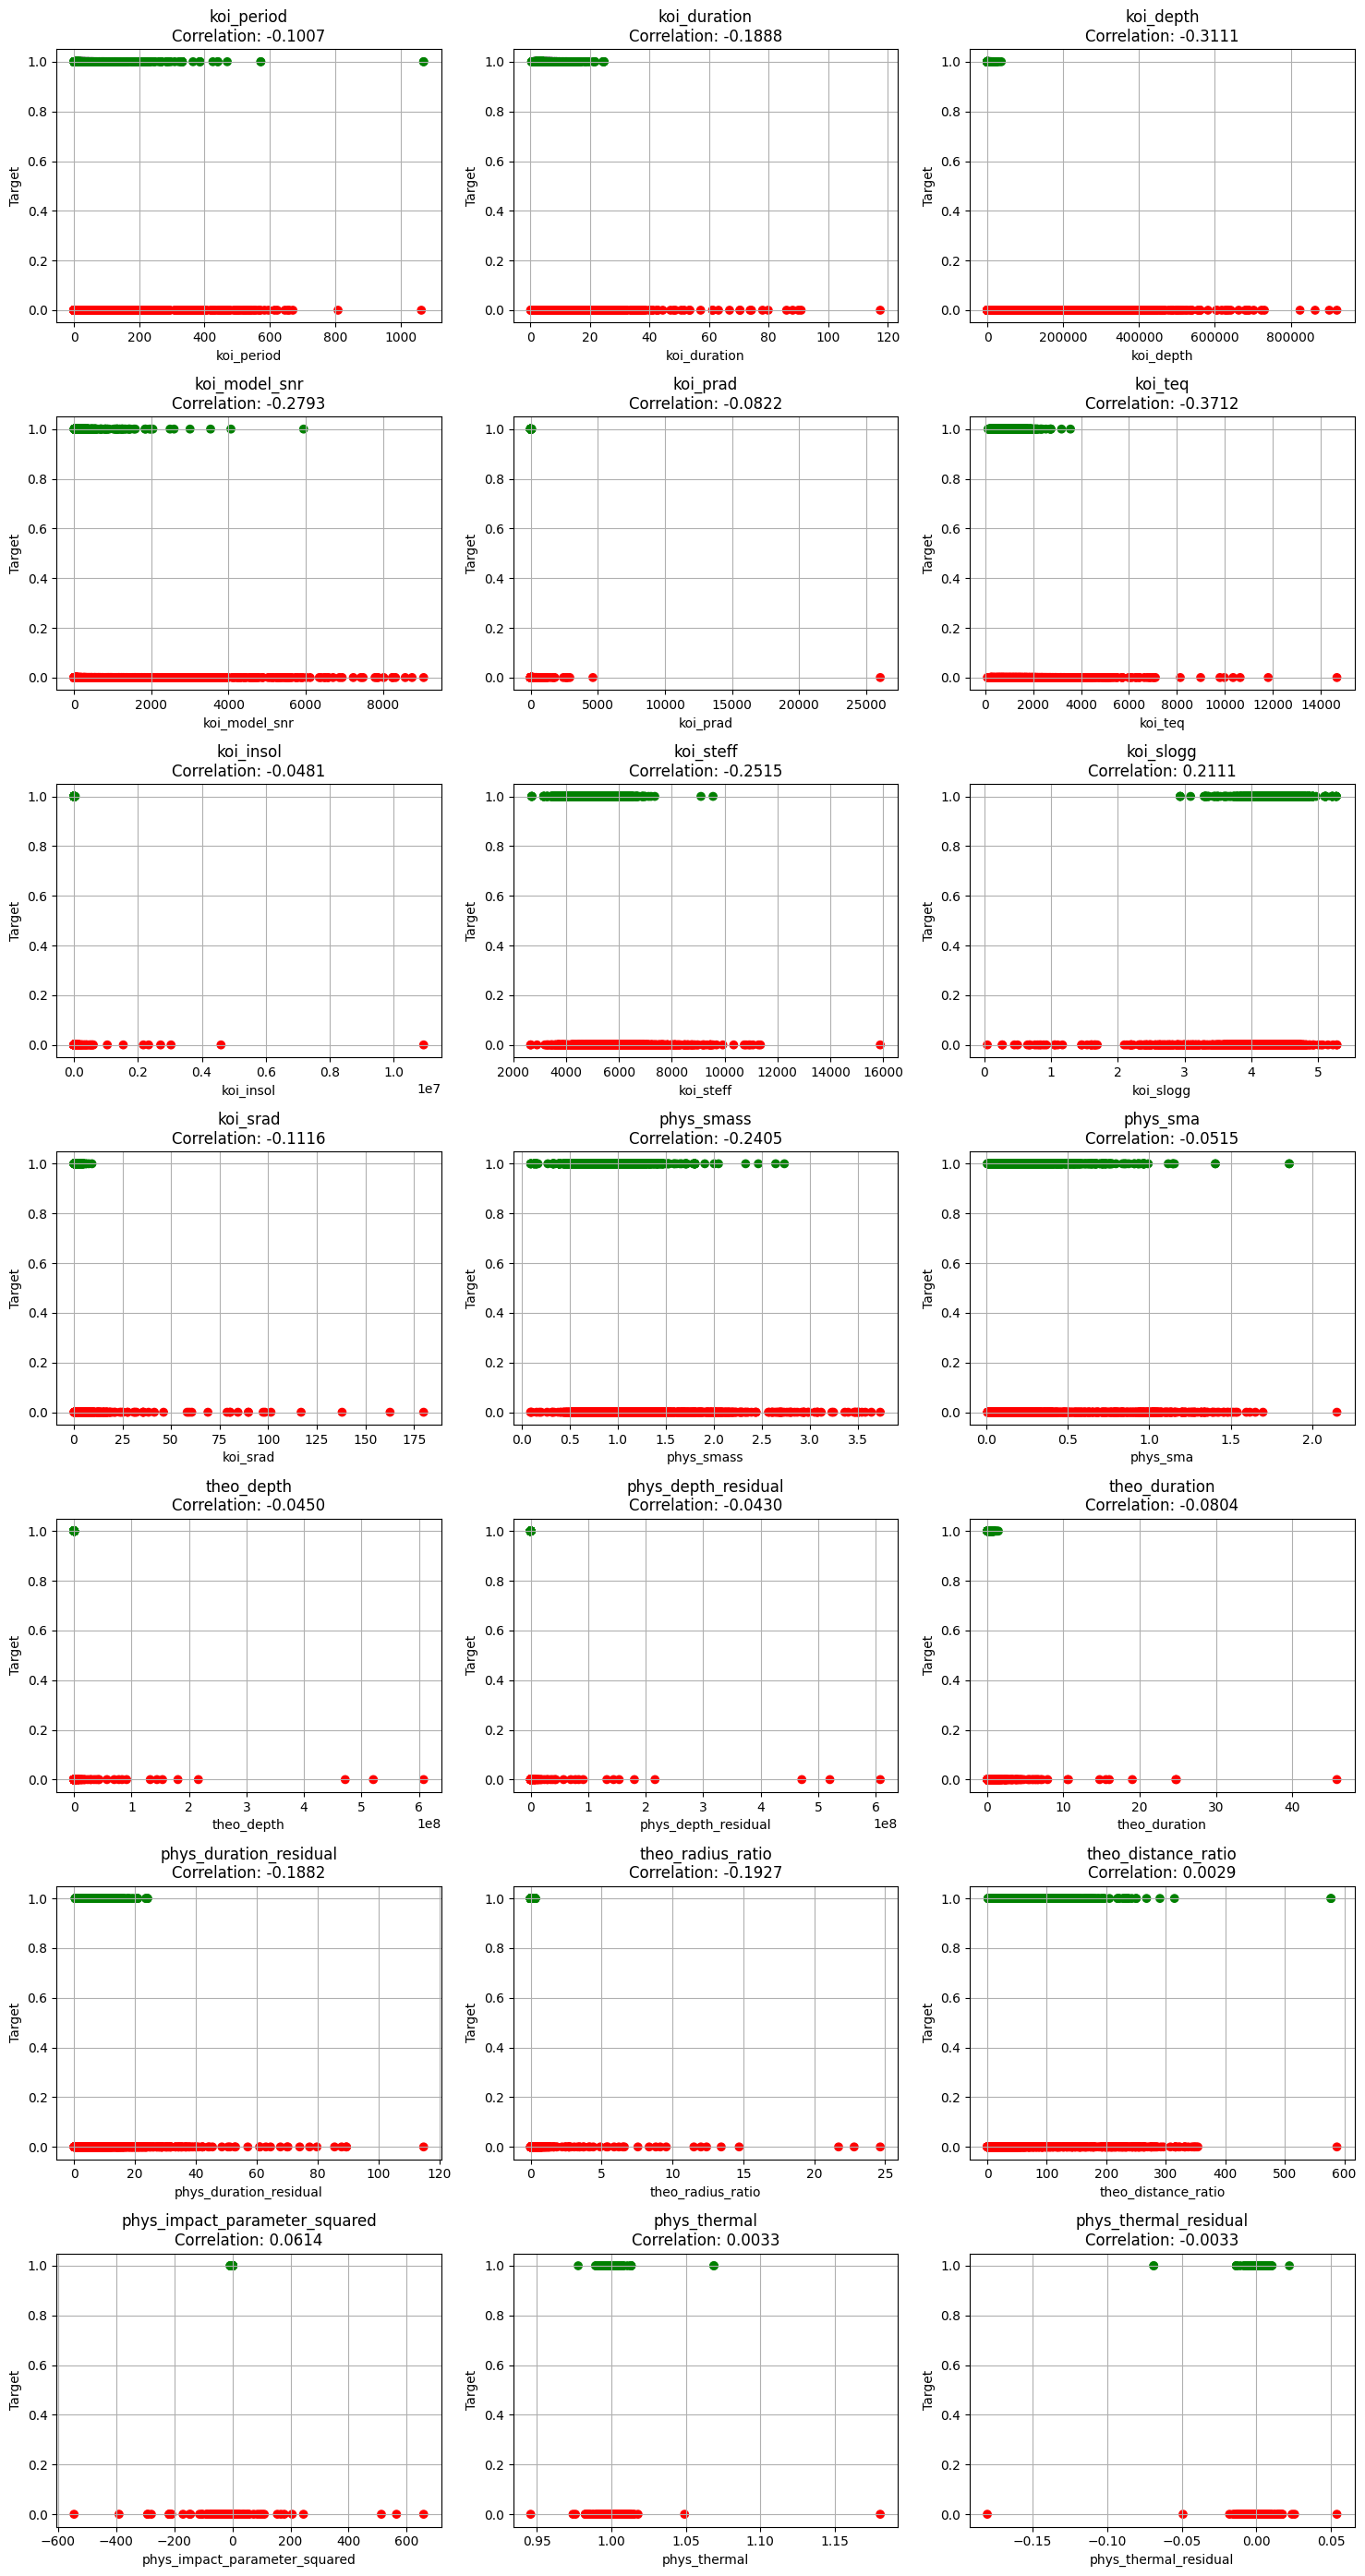

In [5]:
# ---- Correlation Based Feature Selection ---- #

def plot_all_features_vs_target(df, target_col="Target"):
    # This function was generated using Gemini Pro 3.1
    # Get all feature columns (everything except the Target)
    features = [col for col in df.columns if col != target_col]
    n_features = len(features)
    
    # Determine grid size (let's use 3 columns, and however many rows are needed)
    cols = 3
    rows = math.ceil(n_features / cols)
    
    # Initialize the figure and subplots
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    
    # Flatten the axes array to make it easy to iterate over in a 1D loop
    axes = axes.flatten()
    
    # Map the colors once
    point_colors = df[target_col].map({0: "red", 1: "green"})
    
    for i, feature in enumerate(features):
        ax = axes[i]
        
        # Create the scatter plot on the specific subplot (ax)
        ax.scatter(df[feature], df[target_col], c=point_colors)
        
        # Calculate correlation coefficient (dropping NaNs safely for the calculation)
        clean_df = df[[feature, target_col]].dropna()
        if len(clean_df) > 1:
            r = np.corrcoef(clean_df[feature], clean_df[target_col])[0, 1]
        else:
            r = np.nan
            
        # Set title, labels, and grid
        ax.set_title(f"{feature}\nCorrelation: {r:.4f}")
        ax.set_xlabel(feature)
        ax.set_ylabel(target_col)
        ax.grid(True)
        
    # If the grid has more subplots than features, delete the empty ones
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    # Adjust layout so labels don't overlap
    plt.tight_layout()
    plt.show()

# ---- Run Here ---- #

_DATA_FILE_PATH = Path("../data/koi/physics_train/physically_anchored_features_KOI.csv")
df = pd.read_csv(_DATA_FILE_PATH)

considered_features = [col for col in df.columns if (
        col != "Unnamed: 0" and col !="" and col != "Unnamed: 0.1" and col != "kepid" and col != "koi_disposition"
    )]

df_considered = df[considered_features]

# Run the plotting function
plot_all_features_vs_target(df_considered, target_col="Target")